In [1]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 18.4 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install anndata==0.8.0

In [3]:
!pip install -U kaleido

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.6 MB/s eta 0:00:0000:0100:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
import matplotlib.patches as mpatches


In [2]:
orgs = ['mg','mo','cj','ac','xt','dr']
pairs = [list(pair) for pair in itertools.combinations(orgs, 2)]
level = 'eq_supertype'
for org_one, org_two in pairs:
    sm = load_samap('../../Subclustering/PVH/sm_' + org_one + '_' + org_two + '_PVH_09082026.pkl')
    print(org_one, org_two)
    df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])
    a = 0
    keys = {org_one:level,org_two:level}
    D,MappingTable = get_mapping_scores(sm,keys)

    lim_MappingTable = MappingTable.filter(like=org_one + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]
    lim_MappingTable.to_csv('../../Subclustering/PVH/Hypo/' + org_one + '_' + org_two + '_mapping_PVH_09092026_clusters.csv')

mg mo
mg cj
mg ac
mg xt
mg dr
mo cj
mo ac
mo xt
mo dr
cj ac
cj xt
cj dr
ac xt
ac dr
xt dr


In [2]:
#all dfs load
ct = 'PVH'
organisms = ['mg', 'mo', 'cj', 'ac', 'xt', 'dr']
level = 'eq_supertype'

def read_pair(a, b):
    return pd.read_csv(
        f'../../Subclustering/{ct}/Hypo/{a}_{b}_mapping_{ct}_09092026_clusters.csv',
        index_col='Unnamed: 0')

labels = {}
for i, a in enumerate(organisms):
    for b in organisms[i+1:]:
        df = read_pair(a, b)
        labels.setdefault(a, list(df.columns))
        labels.setdefault(b, list(df.index))

mapping = {}
for i, org1 in enumerate(organisms):
    for j, org2 in enumerate(organisms):
        key = f"{org1}_{org2}".upper()
        if i == j:
            u = labels[org1]
            mapping[key] = pd.DataFrame(np.eye(len(u)), index=u, columns=u)
        elif i < j:
            mapping[key] = read_pair(org1, org2)
        else:
            mapping[key] = mapping[f"{org2}_{org1}".upper()].T

In [3]:
organism_rows = {}
for org1 in organisms:
    dfs = [mapping[f"{org1}_{org2}".upper()] for org2 in organisms]
    organism_rows[org1.upper()] = pd.concat(dfs)

In [4]:
pvh_mapping = pd.concat([organism_rows[i.upper()] for i in organisms], axis = 1)

<AxesSubplot:>

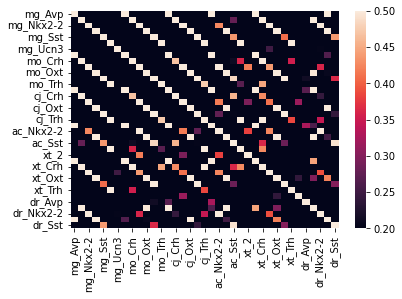

In [5]:
sns.heatmap(pvh_mapping, vmin = .2, vmax = .5)

In [6]:
pvh_mapping

,mg_Avp,mg_Crh,mg_Nkx2-2,mg_Oxt,mg_Sst,mg_Trh,mg_Ucn3,mo_Avp,mo_Crh,mo_Nkx2-2,...,xt_Nkx2-2,xt_Oxt,xt_Sst,xt_Trh,dr_3,dr_Avp,dr_Crh,dr_Nkx2-2,dr_Oxt,dr_Sst
mg_Avp,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817152,0.004535,0.000405,...,0.029643,0.142888,0.000000,0.000008,0.029449,0.166747,0.102639,0.000151,0.561335,0.055739
mg_Crh,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001315,0.697359,0.001328,...,0.001645,0.010536,0.136645,0.022898,0.034395,0.034734,0.544415,0.066369,0.000841,0.083460
mg_Nkx2-2,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003486,0.730006,...,0.513118,0.000062,0.000029,0.018371,0.062793,0.074365,0.000000,0.511181,0.019733,0.007639
mg_Oxt,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.194070,0.000000,0.005799,...,0.027043,0.679834,0.000000,0.000000,0.012571,0.004951,0.000260,0.002708,0.620656,0.001942
mg_Sst,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.004370,0.006008,...,0.007688,0.011637,0.407769,0.000643,0.033337,0.037347,0.000037,0.005135,0.002694,0.438065
mg_Trh,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.020832,0.001432,...,0.001556,0.000257,0.016596,0.703891,0.133460,0.049983,0.018055,0.031984,0.004974,0.051412
mg_Ucn3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000068,0.040555,...,0.250313,0.000622,0.002421,0.000141,0.000588,0.001203,0.000000,0.202790,0.008344,0.003936
mo_Avp,0.817152,0.001315,0.000000,0.194070,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000275,0.004469,0.000000,0.000000,0.142651,0.139873,0.121508,0.001744,0.263741,0.023533
mo_Crh,0.004535,0.697359,0.003486,0.000000,0.004370,0.020832,0.000068,0.000000,1.000000,0.000000,...,0.005033,0.001132,0.021574,0.354356,0.015406,0.021621,0.142726,0.085986,0.002395,0.065942
mo_Nkx2-2,0.000405,0.001328,0.730006,0.005799,0.006008,0.001432,0.040555,0.000000,0.000000,1.000000,...,0.438750,0.000344,0.007865,0.003258,0.126645,0.088273,0.024971,0.360366,0.011580,0.048094


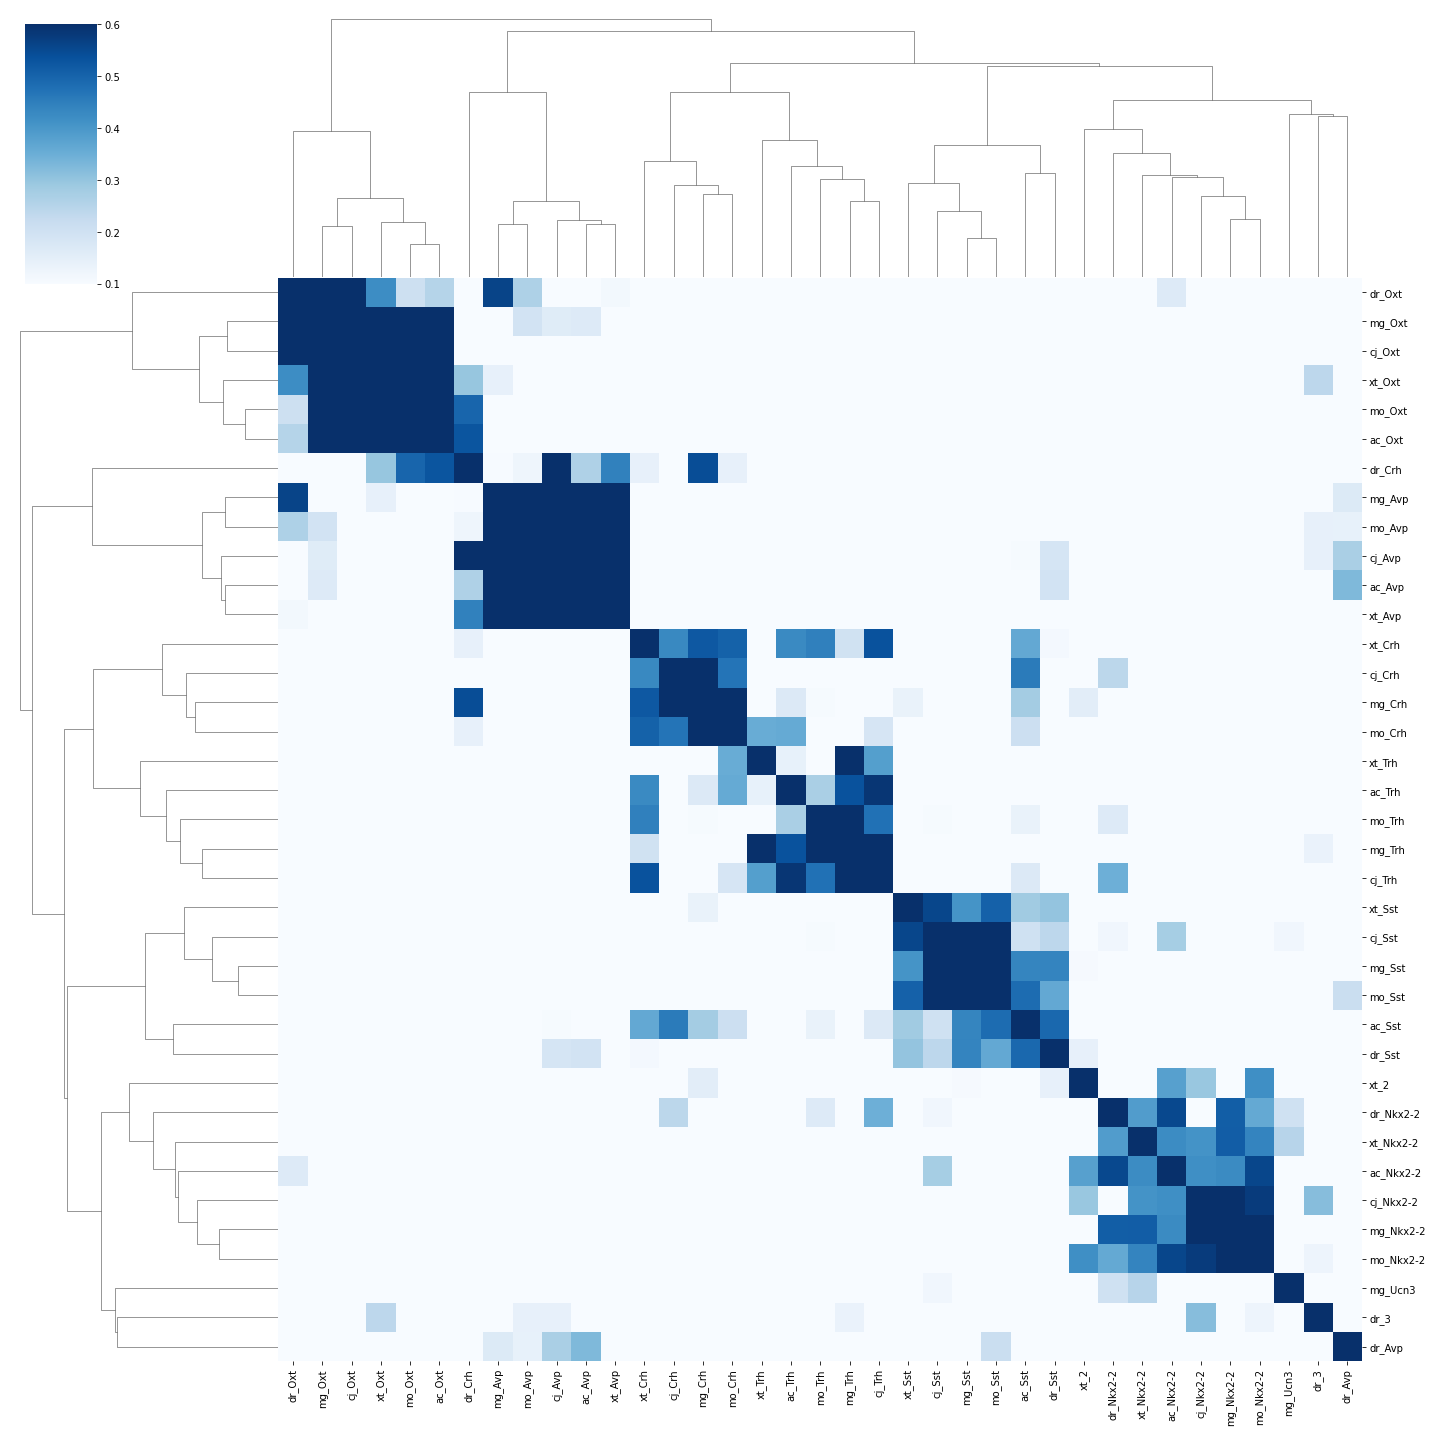

In [7]:
g =sns.clustermap(pvh_mapping, vmax = .6, vmin = .1,cmap = 'Blues',figsize=(20,20))

In [8]:
reorder_row = g.dendrogram_row.reordered_ind
reorder_col = g.dendrogram_col.reordered_ind

In [9]:
pvh_mapping_ord = pvh_mapping.loc[pvh_mapping.index[reorder_row],:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,pvh_mapping.columns[reorder_col]]

In [10]:
pvh_mapping_ord.index

Index(['dr_Oxt', 'mg_Oxt', 'cj_Oxt', 'xt_Oxt', 'mo_Oxt', 'ac_Oxt', 'dr_Crh',
       'mg_Avp', 'mo_Avp', 'cj_Avp', 'ac_Avp', 'xt_Avp', 'xt_Crh', 'cj_Crh',
       'mg_Crh', 'mo_Crh', 'xt_Trh', 'ac_Trh', 'mo_Trh', 'mg_Trh', 'cj_Trh',
       'xt_Sst', 'cj_Sst', 'mg_Sst', 'mo_Sst', 'ac_Sst', 'dr_Sst', 'xt_2',
       'dr_Nkx2-2', 'xt_Nkx2-2', 'ac_Nkx2-2', 'cj_Nkx2-2', 'mg_Nkx2-2',
       'mo_Nkx2-2', 'mg_Ucn3', 'dr_3', 'dr_Avp'],
      dtype='object')

In [11]:
fmo = ['mg_Avp', 'mo_Avp', 'cj_Avp', 'ac_Avp', 'xt_Avp','dr_Avp',
       'mg_Oxt', 'mo_Oxt','cj_Oxt','ac_Oxt','xt_Oxt','dr_Oxt', 
       'mg_Nkx2-2','mo_Nkx2-2','cj_Nkx2-2','ac_Nkx2-2','xt_Nkx2-2','dr_Nkx2-2',
       'mg_Ucn3',
       'mg_Sst', 'mo_Sst','cj_Sst','ac_Sst','xt_Sst','dr_Sst',
       'mg_Crh', 'mo_Crh','cj_Crh','xt_Crh', 'dr_Crh',
       'mg_Trh','mo_Trh','cj_Trh','ac_Trh','xt_Trh']

In [12]:
print(set(fmo) - set(pvh_mapping_ord.index))
print(set(pvh_mapping_ord.index) - set(fmo))

set()
{'dr_3', 'xt_2'}


In [13]:
#changed colors PVH
pvh_mapping_ord = pvh_mapping.loc[fmo,:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,fmo]

category_one = [i[:2] for i in pvh_mapping_ord]
category_two = [i[3:] for i in pvh_mapping_ord]


color_map_one = {"mg": "#C9A185", "mo": "#C9A0DC", 'cj':'#ff7f0e',
                 'ac':'#9467bd',"xt": "#fa9189",
                'dr':'#bcbd22'}
color_map_two = {'Avp':'#4FAE49',
                   'Crh': '#F37F20',
                   'Nkx2-2':'#83C6DB',
                   'Oxt':'#E12228',
                   'Sst':'#EC82B3',
                   'Trh':'#98509F',
                   'Ucn3':'#F6EC39'}

col_colors = pd.DataFrame({
    "Organism": pd.Series(category_one, index=pvh_mapping_ord.columns).map(color_map_one),
    "Celltype": pd.Series(category_two, index=pvh_mapping_ord.columns).map(color_map_two),
})

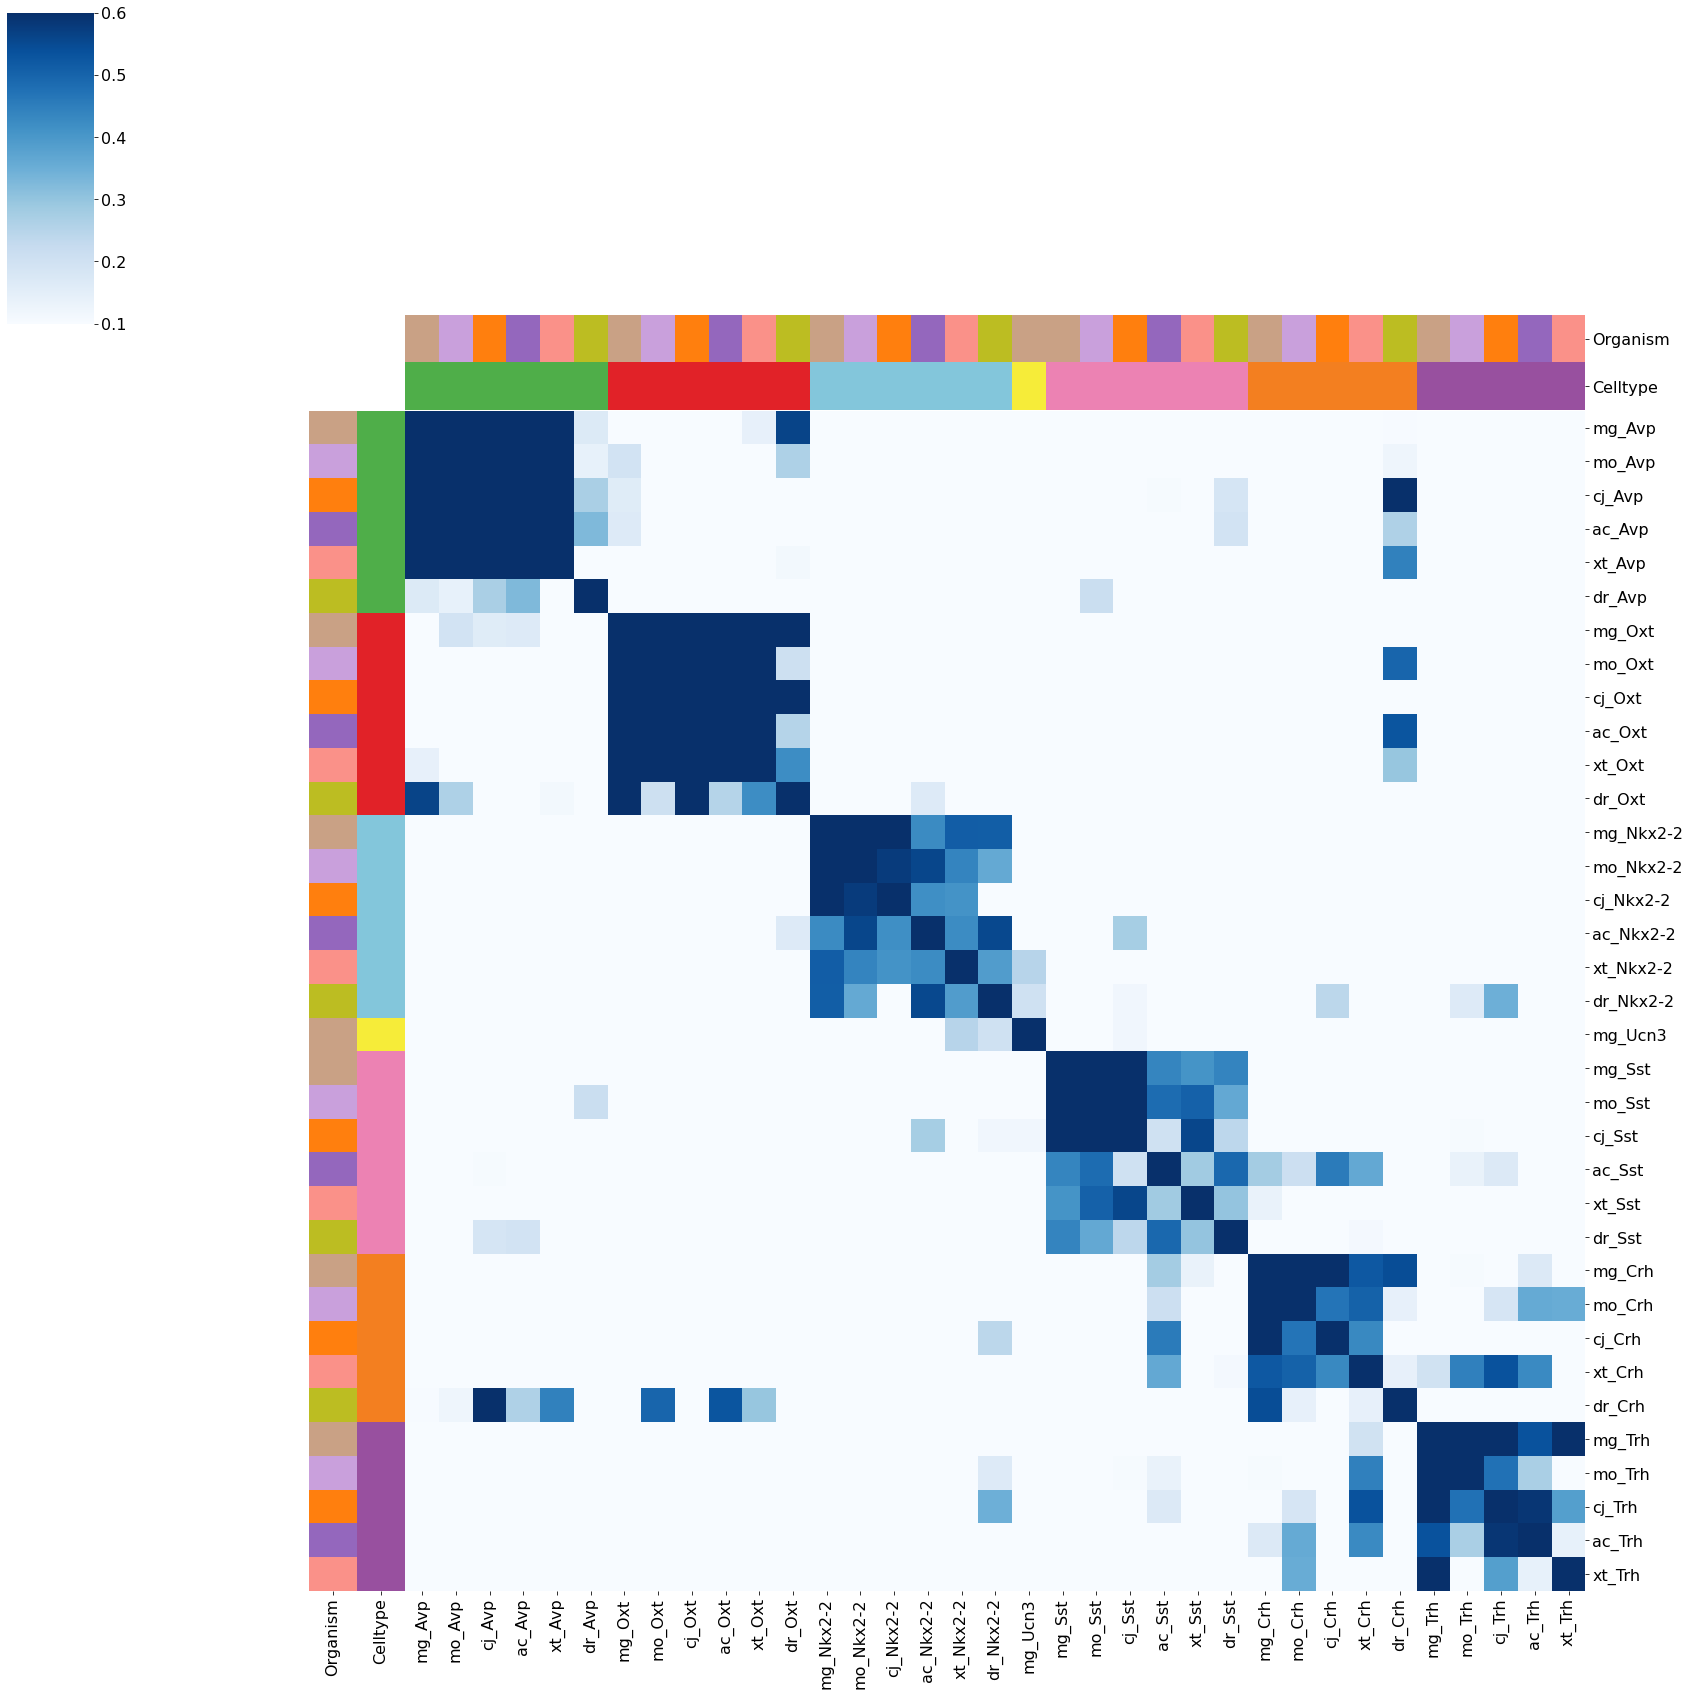

In [14]:
plt.rcParams['font.size'] = 16
g =sns.clustermap(pvh_mapping_ord, vmax = .6,vmin=0.1, cmap = 'Blues',figsize=(24,24),col_colors = col_colors, row_colors = col_colors,row_cluster = False, col_cluster = False)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.savefig('../../Figures/Figures_09132026/Hypoorgs_PVH_heatmap_09092026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_09132026/Hypoorgs_PVH_heatmap_09092026.png', dpi = 600)
plt.savefig('../../Figures/Figures_09132026/Hypoorgs_PVH_heatmap_09092026.pdf',bbox_inches='tight')